<a href="https://colab.research.google.com/github/AmrrinMalikha/weather-forecasting/blob/main/weather_prediction_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter any city name: vellore

City: vellore, IN
Current Temperature: 22°C
Feels Like: 23°C
Humidity: 89%
Min Temperature: 22°C
Max Temperature: 22°C
Weather Description: few clouds
Wind Direction: ESE (121°)
Wind Speed: 2 m/s
Pressure: 1011 hPa
Rain Prediction: No

Overall Model Accuracy: 0.97 (96.9%)

Selected Features (RFE):
1. MaxTemp
2. WindGustDir
3. WindGustSpeed
4. Humidity
5. Pressure

Confusion Matrix:
Actual\Predicted  No Rain  Rain
No Rain            1643     15
Rain                 47    295

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1658
           1       0.95      0.86      0.90       342

    accuracy                           0.97      2000
   macro avg       0.96      0.93      0.94      2000
weighted avg       0.97      0.97      0.97      2000


Future Temperature Predictions:
02:00: 27°C
03:00: 26°C
04:00: 31°C
05:00: 26°C
06:00: 25°C

Future Humidity Predictions:
02:00: 73%
03:00:

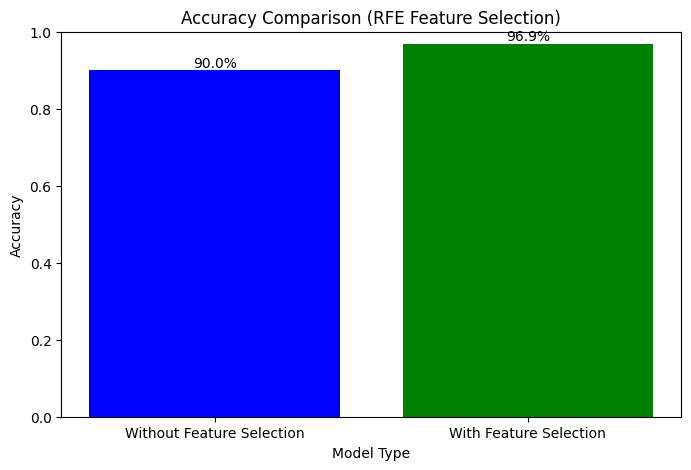

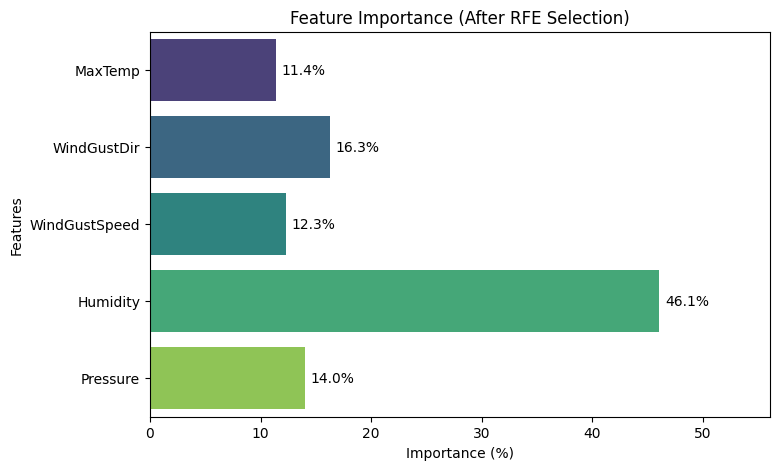

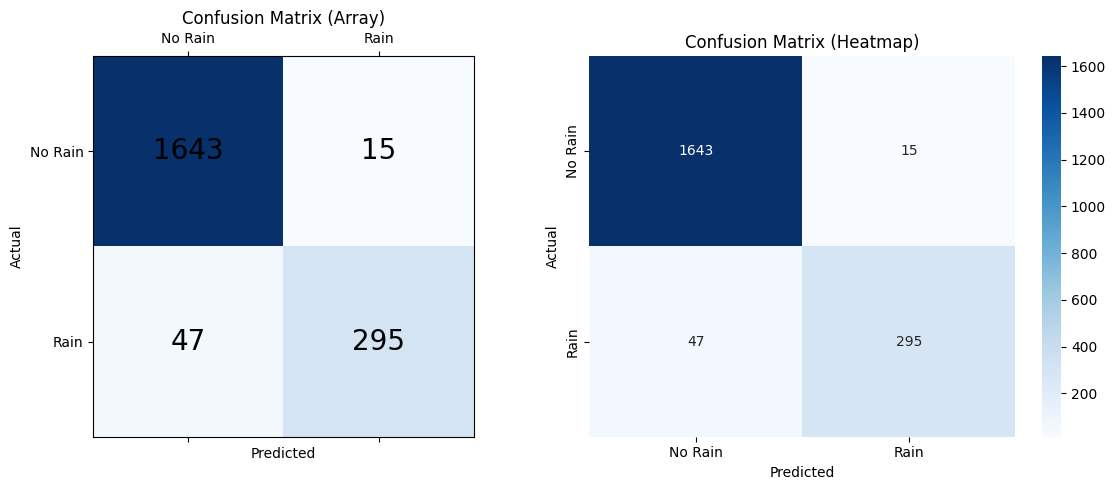

In [ ]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import pytz
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score

# API Key and Base URL for OpenWeatherMap
API_KEY = "785d8f054358cbd3aa7c278c6f466234"
Base_URL = "https://api.openweathermap.org/data/2.5/"

# Fetches current weather data from OpenWeatherMap API for a given city
def get_current_weather(city):
    url = f'{Base_URL}weather?q={city}&appid={API_KEY}&units=metric'
    response = requests.get(url)
    data = response.json()
    return {
        'city': data['name'],
        'current_temp': round(data['main']['temp']),
        'feels_like': round(data['main']['feels_like']),
        'temp_min': round(data['main']['temp_min']),
        'temp_max': round(data['main']['temp_max']),
        'humidity': round(data['main']['humidity']),
        'description': data['weather'][0]['description'],
        'country': data['sys']['country'],
        'wind_gust_dir': round(data['wind']['deg']),
        'pressure': round(data['main']['pressure']),
        'wind_gust_speed': round(data['wind']['speed'])
    }

# Reads and preprocesses historical weather data from CSV file
def read_data(filename):
    df = pd.read_csv("/content/vellore_weather_dataset_expanded-1.csv")
    df.dropna(inplace=True)
    df.drop_duplicates(inplace=True)
    df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})
    return df

# Prepares data by encoding, scaling and selecting features using RFE
def prepare_data(data):
    le = LabelEncoder()
    data['WindGustDir'] = le.fit_transform(data['WindGustDir'])

    X = data[['MinTemp', 'MaxTemp', 'WindGustDir', 'WindGustSpeed', 'Humidity', 'Pressure', 'Temp']]
    y = data['RainTomorrow']

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    estimator = RandomForestClassifier(n_estimators=100, random_state=42)
    selector = RFE(estimator, n_features_to_select=5, step=1)
    X_selected = selector.fit_transform(X_scaled, y)
    selected_features = [X.columns[i] for i in range(len(X.columns)) if selector.support_[i]]

    return X_selected, y, selected_features, le, selector, scaler

# Prepares data for regression tasks with time-shifted target
def regression_data(data, target):
    X = data[[target]]
    y = data[target].shift(-1).dropna()
    X = X.iloc[:-1]
    return X, y

# Trains and evaluates rain prediction model using RandomForest
def train_rain_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    return model, accuracy, cm, report

# Trains and evaluates regression model for continuous values
def train_regression_model(X, y):
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)
    r2 = r2_score(y_test, model.predict(X_test))
    return model, r2

# Predicts future values using trained regression model
def predict_future(model, current_value, feature_name=None):
    predictions = [current_value]
    for _ in range(5):
        if feature_name:
            next_value = model.predict(pd.DataFrame([[predictions[-1]]], columns=[feature_name]))
        else:
            next_value = model.predict(np.array([[predictions[-1]]]))
        predictions.append(next_value[0])
    return predictions[1:]

# Plots accuracy comparison between models with/without feature selection
def plot_accuracy(accuracy_without_fs, accuracy_with_fs):
    labels = ['Without Feature Selection', 'With Feature Selection']
    accuracies = [accuracy_without_fs, accuracy_with_fs]
    percentages = [f"{acc*100:.1f}%" for acc in accuracies]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, accuracies, color=['blue', 'green'])
    plt.ylim(0, 1)
    plt.xlabel('Model Type')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Comparison (RFE Feature Selection)')

    for bar, percentage in zip(bars, percentages):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                percentage,
                ha='center', va='bottom')
    plt.show()

# Visualizes feature importance with percentage values
def plot_feature_importance(model, feature_names):
    importance = model.feature_importances_
    importance_percent = importance * 100

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x=importance_percent, y=feature_names, hue=feature_names,
                    palette='viridis', dodge=False, legend=False)

    for p in ax.patches:
        width = p.get_width()
        ax.text(width + 0.5,
                p.get_y() + p.get_height()/2,
                f'{width:.1f}%',
                ha='left', va='center')

    plt.xlabel('Importance (%)')
    plt.ylabel('Features')
    plt.title('Feature Importance (After RFE Selection)')
    plt.xlim(0, importance_percent.max() + 10)
    plt.show()

# Displays confusion matrix in both array and heatmap formats
def plot_confusion_matrix(cm):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.matshow(cm, cmap='Blues')
    ax1.set_title('Confusion Matrix (Array)')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('Actual')
    ax1.set_xticks([0, 1])
    ax1.set_yticks([0, 1])
    ax1.set_xticklabels(['No Rain', 'Rain'])
    ax1.set_yticklabels(['No Rain', 'Rain'])

    for i in range(2):
        for j in range(2):
            ax1.text(j, i, str(cm[i, j]), ha='center', va='center', color='black', fontsize=20)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
                xticklabels=['No Rain', 'Rain'],
                yticklabels=['No Rain', 'Rain'])
    ax2.set_title('Confusion Matrix (Heatmap)')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('Actual')

    plt.tight_layout()
    plt.show()

# Main function that orchestrates the weather forecasting workflow
def weather_forecast():
    city = input("Enter any city name: ")
    current_weather = get_current_weather(city)
    historical_data = read_data("/content/vellore_weather_dataset_expanded-1.csv")
    X, y, selected_features, le, selector, scaler = prepare_data(historical_data)
    rain_model, rain_accuracy, cm, report = train_rain_model(X, y)

    wind_deg = current_weather['wind_gust_dir'] % 360
    compass_points = [
        ("N", 0, 11.25), ("NNE", 11.25, 33.75), ("NE", 33.75, 56.25),
        ("ENE", 56.25, 78.75), ("E", 78.75, 101.25), ("ESE", 101.25, 123.75),
        ("SE", 123.75, 146.25), ("SSE", 146.25, 168.75), ("S", 168.75, 191.25),
        ("SSW", 191.25, 213.75), ("SW", 213.75, 236.25), ("WSW", 236.25, 258.75),
        ("W", 258.75, 281.25), ("WNW", 281.25, 303.75), ("NW", 303.75, 326.25),
        ("NNW", 326.25, 348.75)
    ]

    compass_direction = next(point for point, start, end in compass_points if start <= wind_deg < end)
    compass_direction_encoded = le.transform([compass_direction])[0] if compass_direction in le.classes_ else -1

    current_data = {
        'MinTemp': current_weather['temp_min'],
        'MaxTemp': current_weather['temp_max'],
        'WindGustDir': compass_direction_encoded,
        'WindGustSpeed': current_weather['wind_gust_speed'],
        'Humidity': current_weather['humidity'],
        'Pressure': current_weather['pressure'],
        'Temp': current_weather['current_temp']
    }

    current_df = pd.DataFrame([current_data])
    current_scaled = scaler.transform(current_df)
    current_selected = selector.transform(current_scaled)
    rain_prediction = rain_model.predict(current_selected)[0]

    temp_x, temp_y = regression_data(historical_data, 'Temp')
    humidity_x, humidity_y = regression_data(historical_data, 'Humidity')
    temp_model, temp_r2 = train_regression_model(temp_x, temp_y)
    humidity_model, humidity_r2 = train_regression_model(humidity_x, humidity_y)

    future_temp = predict_future(temp_model, current_weather['current_temp'], 'Temp')
    future_humidity = predict_future(humidity_model, current_weather['humidity'], 'Humidity')

    timezone = pytz.timezone('Asia/Kolkata')
    now = datetime.now(timezone)
    next_hour = now + timedelta(hours=1)
    next_hour = next_hour.replace(minute=0, second=0, microsecond=0)
    future_times = [(next_hour + timedelta(hours=i)).strftime("%H:00") for i in range(1, 6)]

    print(f"\nCity: {city}, {current_weather['country']}")
    print(f"Current Temperature: {current_weather['current_temp']}°C")
    print(f"Feels Like: {current_weather['feels_like']}°C")
    print(f"Humidity: {current_weather['humidity']}%")
    print(f"Min Temperature: {current_weather['temp_min']}°C")
    print(f"Max Temperature: {current_weather['temp_max']}°C")
    print(f"Weather Description: {current_weather['description']}")
    print(f"Wind Direction: {compass_direction} ({wind_deg}°)")
    print(f"Wind Speed: {current_weather['wind_gust_speed']} m/s")
    print(f"Pressure: {current_weather['pressure']} hPa")
    print(f"Rain Prediction: {'Yes' if rain_prediction else 'No'}")
    print(f"\nOverall Model Accuracy: {rain_accuracy:.2f} ({rain_accuracy*100:.1f}%)")

    print("\nSelected Features (RFE):")
    for i, feature in enumerate(selected_features, 1):
        print(f"{i}. {feature}")

    print("\nConfusion Matrix:")
    print("Actual\\Predicted  No Rain  Rain")
    print(f"No Rain         {cm[0,0]:>7}  {cm[0,1]:>5}")
    print(f"Rain            {cm[1,0]:>7}  {cm[1,1]:>5}")

    print("\nClassification Report:")
    print(report)

    print("\nFuture Temperature Predictions:")
    for time, temp in zip(future_times, future_temp):
        print(f"{time}: {round(temp)}°C")

    print("\nFuture Humidity Predictions:")
    for time, humidity in zip(future_times, future_humidity):
        print(f"{time}: {round(humidity)}%")

    plot_accuracy(0.9, rain_accuracy)
    plot_feature_importance(rain_model, selected_features)
    plot_confusion_matrix(cm)

weather_forecast()